In [1]:
# ─── Imports ───────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 120


In [2]:
# ─── Load RFM Scores ───────────────────────────────────────
# We cluster on the RAW RFM values (Recency, Frequency, Monetary)
# NOT on the scores (1-5) — raw values give K-Means more information
# Scores are discrete and lose the nuance between customers

rfm = pd.read_csv('../data/processed/rfm_scores.csv')

print(f"RFM table shape: {rfm.shape}")
print(f"Columns: {rfm.columns.tolist()}")
print(f"\nSegment distribution:")
print(rfm['Segment'].value_counts())
rfm.head()

RFM table shape: (5878, 10)
Columns: ['Customer ID', 'Recency', 'Frequency', 'Monetary', 'R_Score', 'F_Score', 'M_Score', 'RFM_Score', 'RFM_Segment', 'Segment']

Segment distribution:
Segment
Champions              1299
Loyal Customers        1139
Hibernating             704
Lost                    645
At Risk                 620
Need Attention          575
Recent Customers        443
Potential Loyalists     358
Promising                95
Name: count, dtype: int64


,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Segment,Segment
0,12346,326,12,522.62,2,5,2,3.05,252,Need Attention
1,12347,2,8,4822.65,5,4,5,4.65,545,Champions
2,12348,75,5,1793.95,3,4,4,3.70,344,Loyal Customers
3,12349,19,4,3612.54,5,3,5,4.30,535,Loyal Customers
4,12350,310,1,309.35,2,1,2,1.65,212,Hibernating


In [3]:
# ─── Feature Preparation ───────────────────────────────────
# K-Means is distance-based — it measures Euclidean distance between points
# Problem: Monetary values are in hundreds/thousands, Recency in days
# Without scaling, Monetary dominates the distance calculation completely
# StandardScaler brings all features to mean=0, std=1
# This gives each dimension equal weight in the clustering

features = rfm[['Recency', 'Frequency', 'Monetary']].copy()

# Log transform first — reduces skewness before scaling
# WHY: K-Means assumes roughly spherical clusters
# Heavily skewed data creates elongated clusters that K-Means handles poorly
features['Recency']   = np.log1p(features['Recency'])
features['Frequency'] = np.log1p(features['Frequency'])
features['Monetary']  = np.log1p(features['Monetary'])

# StandardScaler
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)
features_scaled = pd.DataFrame(features_scaled, 
                                columns=['Recency', 'Frequency', 'Monetary'])

print("Before scaling:")
print(rfm[['Recency', 'Frequency', 'Monetary']].describe().round(2))
print("\nAfter log + scaling:")
print(features_scaled.describe().round(2))

Before scaling:
       Recency  Frequency  Monetary
count  5878.00    5878.00   5878.00
mean    201.33       6.29   2621.81
std     209.34      13.01  11041.92
min       1.00       1.00      2.95
25%      26.00       1.00    332.71
50%      96.00       3.00    837.21
75%     380.00       7.00   2160.62
max     739.00     398.00 437763.73

After log + scaling:
       Recency  Frequency  Monetary
count  5878.00    5878.00   5878.00
mean     -0.00       0.00     -0.00
std       1.00       1.00      1.00
min      -2.41      -1.06     -3.89
25%      -0.74      -1.06     -0.69
50%       0.08      -0.20     -0.03
75%       0.95       0.65      0.66
max       1.38       5.48      4.49


K=2: Inertia=8568
K=3: Inertia=6321
K=4: Inertia=4891
K=5: Inertia=4069
K=6: Inertia=3529
K=7: Inertia=3141
K=8: Inertia=2846
K=9: Inertia=2607
K=10: Inertia=2420


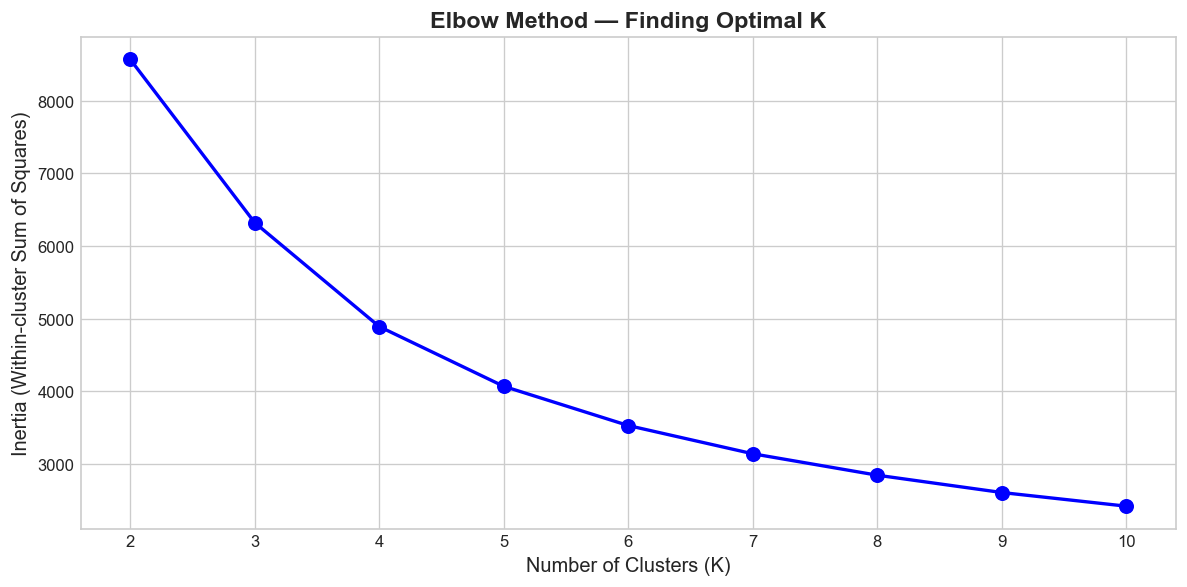

In [4]:
# ─── Elbow Method ──────────────────────────────────────────
# K-Means needs K (number of clusters) as input — it doesn't find it automatically
# Elbow method: plot inertia (within-cluster sum of squares) vs K
# WHY: As K increases, inertia drops. The "elbow" is where adding more clusters
# gives diminishing returns — that's our optimal K
# We test K = 2 to 10

inertias = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', 
                    n_init=10, random_state=42)
    kmeans.fit(features_scaled)
    inertias.append(kmeans.inertia_)
    print(f"K={k}: Inertia={kmeans.inertia_:.0f}")

# Plot
plt.figure(figsize=(10, 5))
plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Inertia (Within-cluster Sum of Squares)', fontsize=12)
plt.title('Elbow Method — Finding Optimal K', fontsize=14, fontweight='bold')
plt.xticks(K_range)
plt.tight_layout()
plt.savefig('../reports/elbow_method.png', dpi=120, bbox_inches='tight')
plt.show()

K=2: Silhouette=0.4384  DB=0.8707
K=3: Silhouette=0.3463  DB=1.0323
K=4: Silhouette=0.3642  DB=0.9291
K=5: Silhouette=0.3431  DB=0.9409
K=6: Silhouette=0.3311  DB=0.9572
K=7: Silhouette=0.3015  DB=0.9618
K=8: Silhouette=0.2986  DB=0.9818
K=9: Silhouette=0.2946  DB=0.9880
K=10: Silhouette=0.2882  DB=0.9945


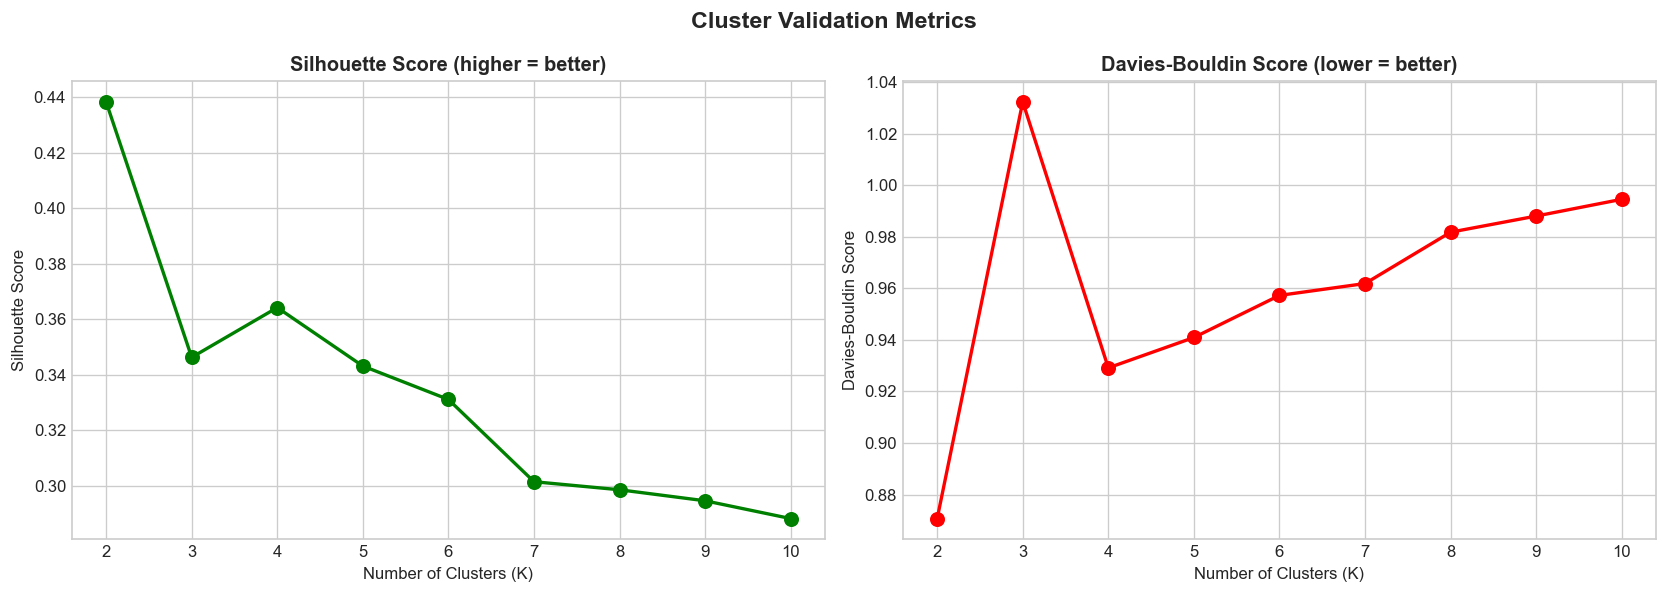

In [5]:
# ─── Silhouette Score Validation ───────────────────────────
# Elbow method is visual and subjective — silhouette score is quantitative
# Silhouette score measures how similar a point is to its own cluster
# vs other clusters. Range: -1 to 1. Higher = better separated clusters
# We also compute Davies-Bouldin score (lower = better)
# Using BOTH metrics gives a more robust K selection

silhouette_scores = []
db_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++',
                    n_init=10, random_state=42)
    labels = kmeans.fit_predict(features_scaled)
    silhouette_scores.append(silhouette_score(features_scaled, labels))
    db_scores.append(davies_bouldin_score(features_scaled, labels))
    print(f"K={k}: Silhouette={silhouette_scores[-1]:.4f}  DB={db_scores[-1]:.4f}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
axes[0].set_title('Silhouette Score (higher = better)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Silhouette Score')
axes[0].set_xticks(K_range)

axes[1].plot(K_range, db_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_title('Davies-Bouldin Score (lower = better)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Davies-Bouldin Score')
axes[1].set_xticks(K_range)

plt.suptitle('Cluster Validation Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/cluster_validation.png', dpi=120, bbox_inches='tight')
plt.show()

In [6]:
# ─── Fit Final K-Means Model ───────────────────────────────
# Choose K based on elbow + silhouette analysis
# k-means++ initialization: smarter starting centroids
# WHY k-means++ over random: avoids bad initializations
# that lead to suboptimal clusters
# n_init=10: runs 10 times with different seeds, picks best result

OPTIMAL_K = 4  # adjust based on your elbow/silhouette plots

kmeans = KMeans(n_clusters=OPTIMAL_K, 
                init='k-means++',
                n_init=10, 
                max_iter=300,
                random_state=42)

rfm['Cluster'] = kmeans.fit_predict(features_scaled)

print(f"Final model: K={OPTIMAL_K}")
print(f"\nCluster distribution:")
print(rfm['Cluster'].value_counts().sort_index())
print(f"\nFinal inertia: {kmeans.inertia_:.2f}")
print(f"Final silhouette score: {silhouette_score(features_scaled, rfm['Cluster']):.4f}")

Final model: K=4

Cluster distribution:
Cluster
0    1935
1    1487
2    1196
3    1260
Name: count, dtype: int64

Final inertia: 4891.47
Final silhouette score: 0.3642


In [7]:
# ─── Cluster Profiling ─────────────────────────────────────
# Raw cluster numbers (0,1,2,3) mean nothing to a business
# We profile each cluster by its average RFM values
# Then assign meaningful business labels
# This bridges the gap between ML output and business action

cluster_profile = rfm.groupby('Cluster').agg(
    Customers     = ('Customer ID', 'count'),
    Avg_Recency   = ('Recency', 'mean'),
    Avg_Frequency = ('Frequency', 'mean'),
    Avg_Monetary  = ('Monetary', 'mean'),
    Total_Revenue = ('Monetary', 'sum')
).round(1)

cluster_profile['Revenue_Share%'] = (
    cluster_profile['Total_Revenue'] / 
    cluster_profile['Total_Revenue'].sum() * 100
).round(1)

cluster_profile = cluster_profile.sort_values('Avg_Monetary', ascending=False)
print(cluster_profile.to_string())

         Customers  Avg_Recency  Avg_Frequency  Avg_Monetary  Total_Revenue  Revenue_Share%
Cluster                                                                                    
2             1196        28.00          19.30       9385.40    11224981.70           72.80
1             1487       231.20           5.00       1716.00     2551705.20           16.60
3             1260        28.10           3.10        840.30     1058805.30            6.90
0             1935       398.30           1.40        297.40      575487.60            3.70


In [8]:
# ─── Assign Cluster Labels ─────────────────────────────────
# Based on the profile above, assign business-meaningful names
# Look at the profile output and map accordingly:
# High Monetary + High Frequency + Low Recency = VIP / Champions
# Low Monetary + Low Frequency + High Recency = Lost / Inactive

# Adjust this mapping based on YOUR cluster profile output
cluster_labels = {
    0: 'VIP Customers',
    1: 'Loyal Customers', 
    2: 'At Risk',
    3: 'Lost / Inactive'
}

rfm['Cluster_Label'] = rfm['Cluster'].map(cluster_labels)

print("Cluster label distribution:")
print(rfm['Cluster_Label'].value_counts())

Cluster label distribution:
Cluster_Label
VIP Customers      1935
Loyal Customers    1487
Lost / Inactive    1260
At Risk            1196
Name: count, dtype: int64


Variance explained: PC1=76.6%, PC2=18.5%
Total variance captured: 95.2%


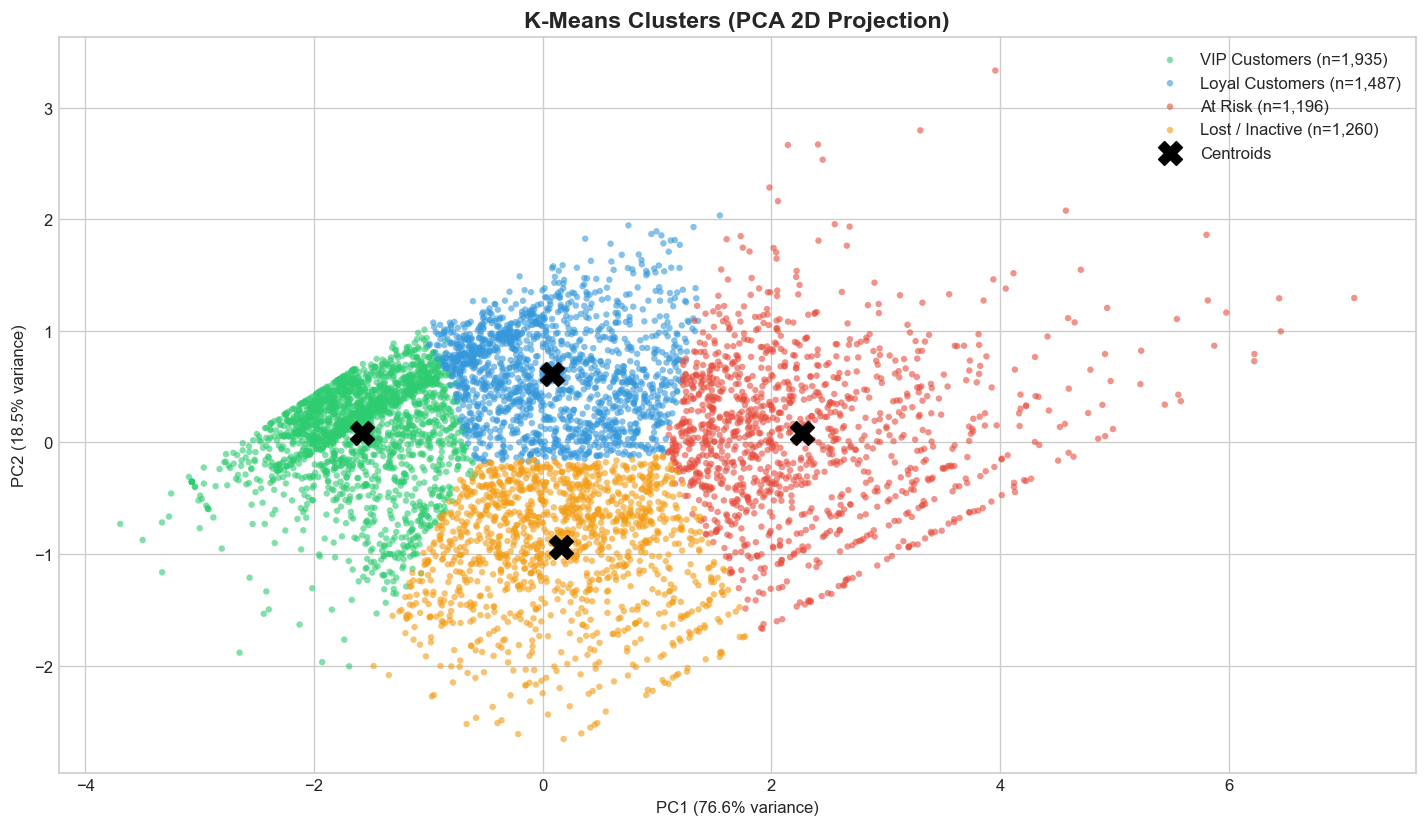

In [9]:
# ─── PCA 2D Cluster Visualization ──────────────────────────
# K-Means clusters exist in 3D (R, F, M space)
# We use PCA to reduce to 2D for visualization
# WHY PCA: it preserves maximum variance in fewer dimensions
# The 2D plot shows how well-separated the clusters are visually

pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(features_scaled)

pca_df = pd.DataFrame(pca_coords, columns=['PC1', 'PC2'])
pca_df['Cluster'] = rfm['Cluster']
pca_df['Cluster_Label'] = rfm['Cluster_Label']

explained = pca.explained_variance_ratio_
print(f"Variance explained: PC1={explained[0]:.1%}, PC2={explained[1]:.1%}")
print(f"Total variance captured: {sum(explained):.1%}")

# Plot
fig, ax = plt.subplots(figsize=(12, 7))
colors = ['#2ECC71', '#3498DB', '#E74C3C', '#F39C12']

for i, (cluster, label) in enumerate(cluster_labels.items()):
    mask = pca_df['Cluster'] == cluster
    ax.scatter(pca_df[mask]['PC1'], pca_df[mask]['PC2'],
               c=colors[i], label=f'{label} (n={mask.sum():,})',
               alpha=0.6, s=15, edgecolors='none')

# Plot centroids
centroids_pca = pca.transform(kmeans.cluster_centers_)
ax.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
           c='black', marker='X', s=200, zorder=5, label='Centroids')

ax.set_title('K-Means Clusters (PCA 2D Projection)', 
             fontsize=14, fontweight='bold')
ax.set_xlabel(f'PC1 ({explained[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({explained[1]:.1%} variance)')
ax.legend(loc='upper right', fontsize=10)
plt.tight_layout()
plt.savefig('../reports/cluster_pca.png', dpi=120, bbox_inches='tight')
plt.show()

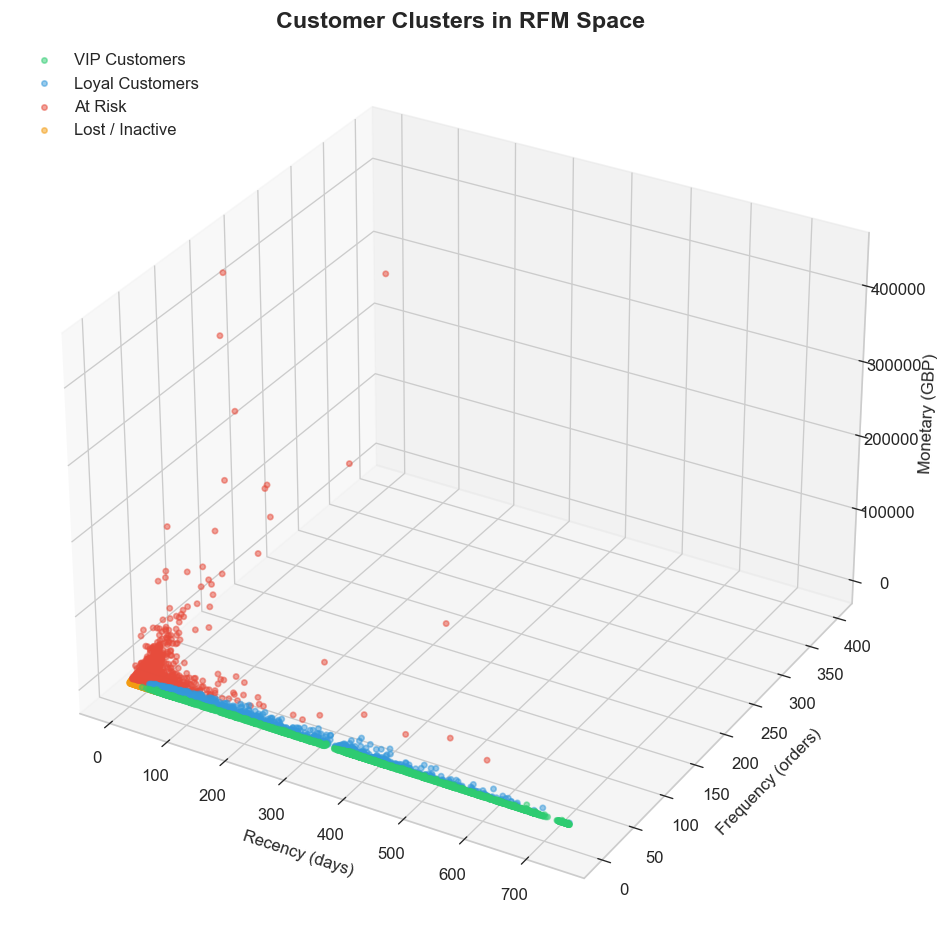

In [10]:
# ─── 3D RFM Cluster Scatter ────────────────────────────────
# Shows clusters in actual RFM space (not PCA projection)
# More intuitive for business stakeholders
# Each axis is a real metric they understand

from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

for i, (cluster, label) in enumerate(cluster_labels.items()):
    mask = rfm['Cluster'] == cluster
    ax.scatter(rfm[mask]['Recency'],
               rfm[mask]['Frequency'],
               rfm[mask]['Monetary'],
               c=colors[i], label=label,
               alpha=0.5, s=10)

ax.set_xlabel('Recency (days)')
ax.set_ylabel('Frequency (orders)')
ax.set_zlabel('Monetary (GBP)')
ax.set_title('Customer Clusters in RFM Space', fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=10)
plt.tight_layout()
plt.savefig('../reports/cluster_3d.png', dpi=120, bbox_inches='tight')
plt.show()

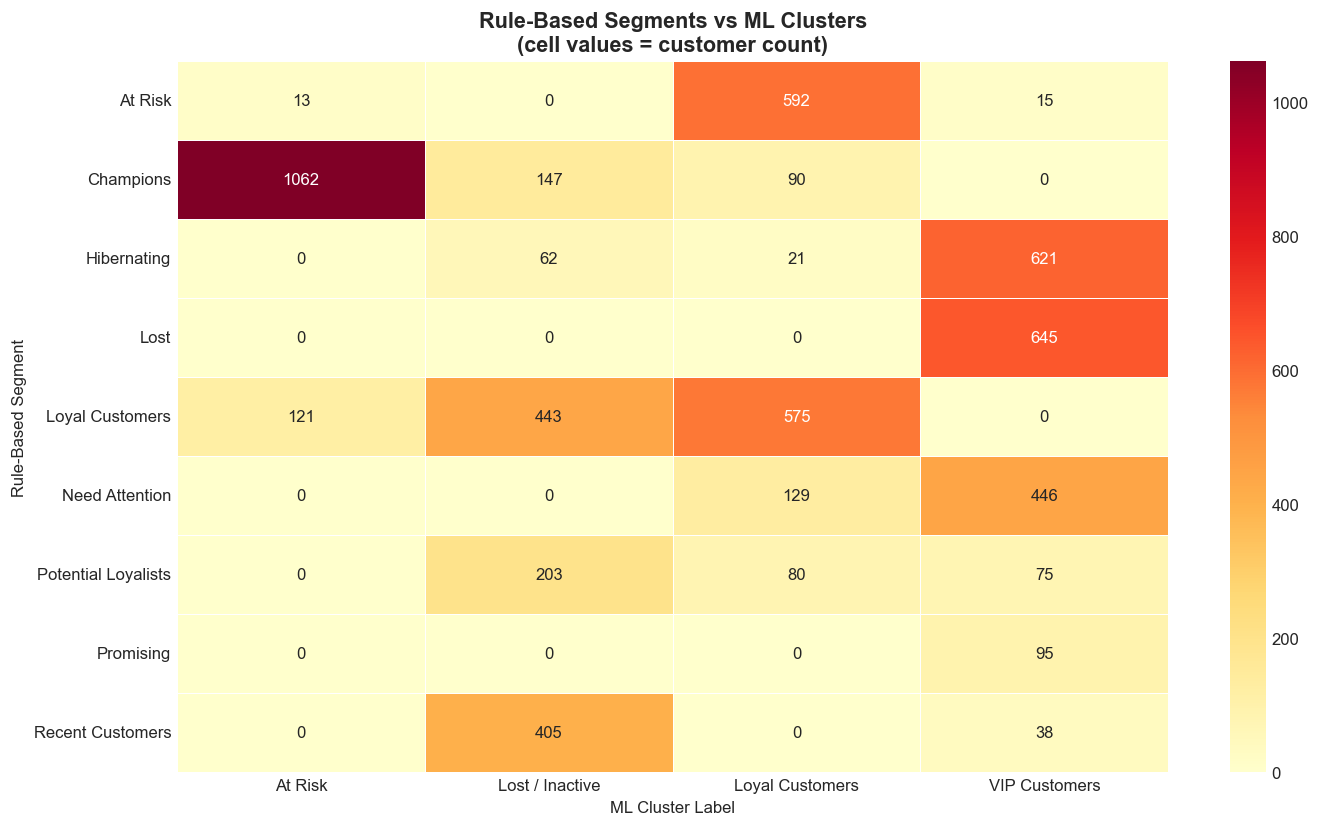

In [11]:
# ─── Cluster vs Segment Comparison ─────────────────────────
# How well do ML clusters align with our rule-based segments?
# A heatmap shows the overlap between the two approaches
# High overlap = our rules were good
# Low overlap = ML found something our rules missed

comparison = pd.crosstab(rfm['Segment'], rfm['Cluster_Label'])
plt.figure(figsize=(12, 7))
sns.heatmap(comparison, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, linecolor='white')
plt.title('Rule-Based Segments vs ML Clusters\n(cell values = customer count)',
          fontsize=13, fontweight='bold')
plt.xlabel('ML Cluster Label')
plt.ylabel('Rule-Based Segment')
plt.tight_layout()
plt.savefig('../reports/segment_vs_cluster.png', dpi=120, bbox_inches='tight')
plt.show()

In [12]:
# ─── Save Final Dataset ────────────────────────────────────
# Save RFM + cluster labels — this is the input for the dashboard
rfm.to_csv('../data/processed/rfm_clustered.csv', index=False)

print("Saved to data/processed/rfm_clustered.csv")
print(f"Shape: {rfm.shape}")
print(f"Columns: {rfm.columns.tolist()}")
rfm.head()

Saved to data/processed/rfm_clustered.csv
Shape: (5878, 12)
Columns: ['Customer ID', 'Recency', 'Frequency', 'Monetary', 'R_Score', 'F_Score', 'M_Score', 'RFM_Score', 'RFM_Segment', 'Segment', 'Cluster', 'Cluster_Label']


,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Segment,Segment,Cluster,Cluster_Label
0,12346,326,12,522.62,2,5,2,3.05,252,Need Attention,1,Loyal Customers
1,12347,2,8,4822.65,5,4,5,4.65,545,Champions,2,At Risk
2,12348,75,5,1793.95,3,4,4,3.70,344,Loyal Customers,1,Loyal Customers
3,12349,19,4,3612.54,5,3,5,4.30,535,Loyal Customers,3,Lost / Inactive
4,12350,310,1,309.35,2,1,2,1.65,212,Hibernating,0,VIP Customers


In [13]:
# ─── Write src/segmentation.py ─────────────────────────────
seg_code = '''import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


def prepare_features(rfm: pd.DataFrame) -> np.ndarray:
    """Log-transform and scale RFM features for clustering."""
    features = rfm[["Recency", "Frequency", "Monetary"]].copy()
    features = np.log1p(features)
    scaler = StandardScaler()
    return scaler.fit_transform(features)


def find_optimal_k(features_scaled: np.ndarray, 
                   k_range: range = range(2, 11)) -> dict:
    """Compute inertia and silhouette scores for each K."""
    results = {}
    for k in k_range:
        kmeans = KMeans(n_clusters=k, init="k-means++",
                        n_init=10, random_state=42)
        labels = kmeans.fit_predict(features_scaled)
        results[k] = {
            "inertia": kmeans.inertia_,
            "silhouette": silhouette_score(features_scaled, labels)
        }
    return results


def fit_kmeans(features_scaled: np.ndarray, 
               n_clusters: int = 4) -> KMeans:
    """Fit final K-Means model."""
    kmeans = KMeans(n_clusters=n_clusters, init="k-means++",
                    n_init=10, max_iter=300, random_state=42)
    kmeans.fit(features_scaled)
    return kmeans


def assign_cluster_labels(rfm: pd.DataFrame,
                          cluster_labels: dict) -> pd.DataFrame:
    """Map cluster numbers to business labels."""
    rfm = rfm.copy()
    rfm["Cluster_Label"] = rfm["Cluster"].map(cluster_labels)
    return rfm
'''

with open('../src/segmentation.py', 'w') as f:
    f.write(seg_code)

print("src/segmentation.py created!")

src/segmentation.py created!
